# Polynomial Regression

In [2]:
# import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

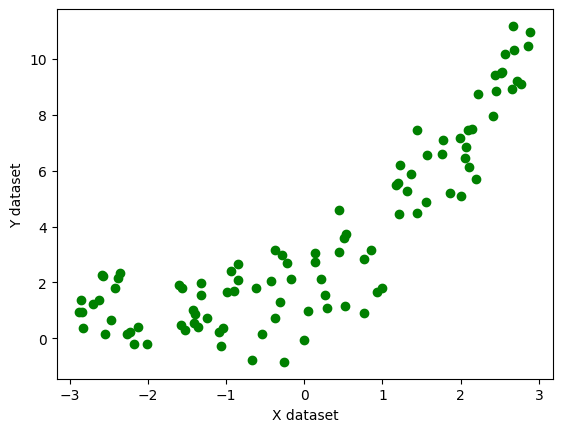

In [8]:
X = 6 * np.random.rand(100,1) -3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100,1)
# quadratic equation used- y=0.5x ^ 2+1.5 + 2 + outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25,random_state=42)

In [10]:
# Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train,y_train)
y_pred = regression_1.predict(X_test)

In [11]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.7392812223767719


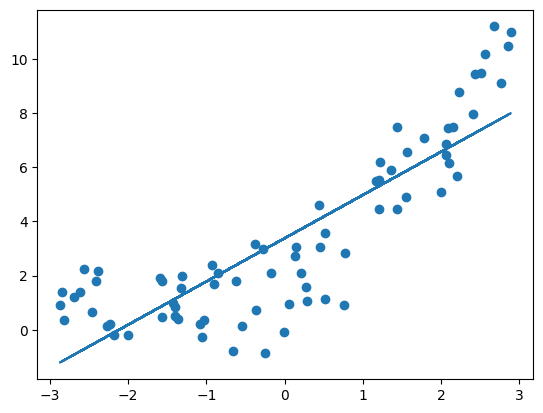

In [12]:
# Visualize the best fit line by regression model
plt.scatter(X_train,y_train)
plt.plot(X_train,regression_1.predict(X_train))


In [13]:
# Polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [16]:
# Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_2 = LinearRegression()
regression_2.fit(X_train_poly,y_train)
y_pred = regression_2.predict(X_test_poly)

In [17]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.9093217548212246


In [18]:
regression_2.coef_

array([[0.        , 1.57921944, 0.49539361]])

In [19]:
regression_2.intercept_

array([1.91562505])

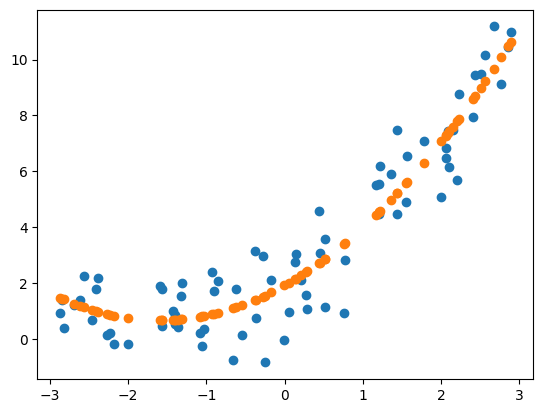

In [23]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression_2.predict(X_train_poly))

### Pipeline concepts

In [34]:
from sklearn.pipeline import Pipeline
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)

    poly_features = PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ('poly_features', poly_features),
        ('lin_reg', lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new = poly_regression.predict(X_new)

    # Plotting prediction line
    plt.plot(X_new,y_pred_new,'r',label = 'Degree' + str(degree),linewidth = 3)
    plt.plot(X_train,y_train,'b.',linewidth = 3)
    plt.plot(X_test,y_test,'g.', linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis([-4,4,0,10])
    plt.show()

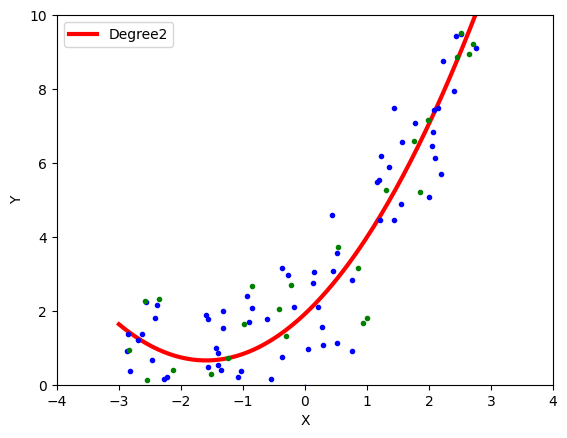

In [35]:
poly_regression(2)

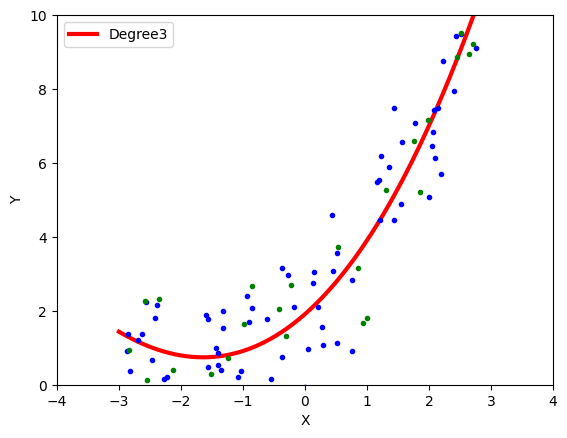

In [36]:
poly_regression(3)

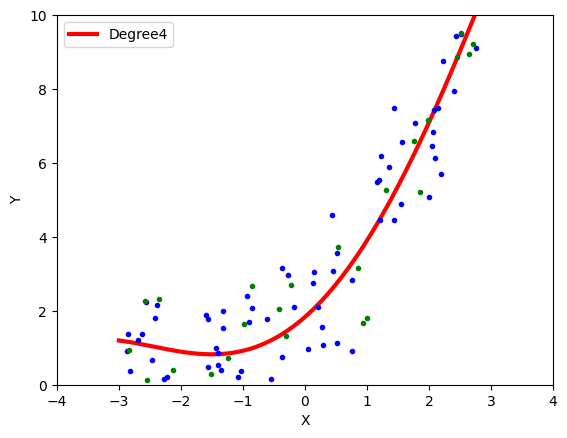

In [37]:
poly_regression(4)

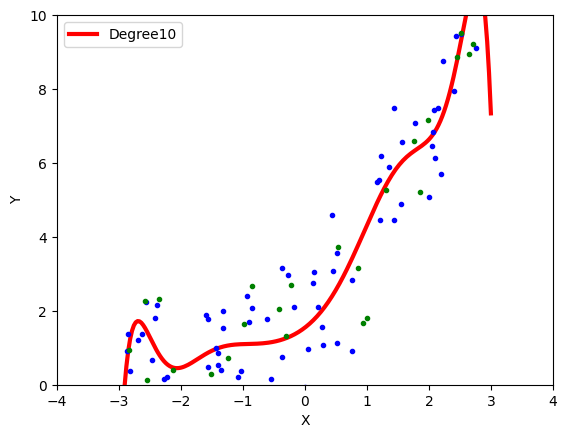

In [38]:
poly_regression(10)